# Steering Modality — Driving Behaviour MLP from UAH-DriveSet

**Driver Fatigue Detection — Signal Modality Comparison**
*BSc Computing Dissertation — Leon Dupree*

This notebook trains and evaluates a small MLP that classifies windows of
driving telemetry as **normal** or **drowsy** using engineered features
derived from the UAH-DriveSet smartphone-recorded driving data.

**Dataset:** UAH-DriveSet by Romera, Bergasa & Arroyo (ITSC 2016).
Naturalistic driving recorded with the DriveSafe smartphone app: 6 drivers,
6 vehicles, 3 behaviours (normal, drowsy, aggressive), 2 road types
(motorway, secondary), 500+ minutes total. Available at:
http://www.robesafe.uah.es/personal/eduardo.romera/uah-driveset/

**Per-window features used:**
- Speed: mean, std, min, max (km/h, from GPS)
- Acceleration: longitudinal mean and std (m/s², from accelerometer)
- Acceleration: lateral mean and std (m/s², proxy for steering)
- Yaw rate (deg/s) mean and std (from gyroscope, proxy for cornering)
- Lateral position deviation if available

**Methodology notes:**
- Binary classification: NORMAL vs DROWSY (aggressive class is excluded
  because it's not the focus of fatigue detection — but the dataset's
  three-class nature is documented in the dissertation methodology).
- **Driver-level train/val/test split** — different drivers in train vs
  test, mirroring the subject-level split used for the eye modality.
  6 drivers gives us roughly 4 train / 1 val / 1 test (small test set,
  but methodologically clean).
- Reported metrics: accuracy, precision, recall, F1-score, confusion matrix.


## 1. Setup and imports

In [1]:
import sys
import re
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

# --- Resolve project root correctly ---
cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

print("Working directory:", cwd)
print("Project root:", PROJECT_ROOT)

# --- Ensure Python can see /src ---
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("src exists:", (PROJECT_ROOT / "src").exists())

# --- Import your model ---
from src.steering.model import SteeringMLP

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

# --- Data folder ---
DATA_DIR = PROJECT_ROOT / "data" / "UAH-DriveSet"

if not DATA_DIR.exists():
    raise FileNotFoundError(f"Dataset folder not found: {DATA_DIR}")

print("✅ Using DATA_DIR:", DATA_DIR)

Working directory: C:\Dissertation\fatigue-detection\notebooks
Project root: C:\Dissertation\fatigue-detection
src exists: True
PyTorch: 2.5.1+cu121
CUDA: True
✅ Using DATA_DIR: C:\Dissertation\fatigue-detection\data\UAH-DriveSet


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cuda


## 2. Locate the UAH-DriveSet dataset

### Expected folder structure

Download UAH-DriveSet from:
http://www.robesafe.uah.es/personal/eduardo.romera/uah-driveset/

Extract into the `data/` folder. The expected layout is:

```
fatigue-detection/data/
└── uah_driveset/
    ├── D1/
    │   ├── 20151110175712-26km-D1-NORMAL-MOTORWAY/
    │   │   ├── RAW_GPS.txt
    │   │   ├── RAW_ACCELEROMETERS.txt
    │   │   ├── PROC_LANE_DETECTION.txt
    │   │   ├── SEMANTIC_FINAL.txt
    │   │   └── ... (other files)
    │   ├── 20151110180043-26km-D1-DROWSY-MOTORWAY/
    │   └── ...
    ├── D2/
    └── ... (D1 through D6)
```

Each driver folder contains multiple "trip" subfolders, with the trip name
encoding the driver, behaviour (NORMAL/DROWSY/AGGRESSIVE), and road type.

The notebook tries several common parent folder names automatically.


In [3]:
print("✅ Using DATA_DIR:", DATA_DIR)

# ============================
# BUILD trips_df (ADD THIS)
# ============================

import pandas as pd

trip_rows = []

for driver_dir in sorted(DATA_DIR.glob("D*")):
    if not driver_dir.is_dir():
        continue

    for trip_dir in sorted(driver_dir.iterdir()):
        if not trip_dir.is_dir():
            continue

        name = trip_dir.name.upper()

        if "NORMAL" in name:
            behavior = "NORMAL"
        elif "DROWSY" in name:
            behavior = "DROWSY"
        elif "AGGRESSIVE" in name:
            behavior = "AGGRESSIVE"
        else:
            behavior = "UNKNOWN"

        road_type = name.split("-")[-1] if "-" in name else "UNKNOWN"

        trip_rows.append({
            "driver": driver_dir.name,
            "trip": trip_dir.name,
            "behavior": behavior,
            "road_type": road_type,
            "path": trip_dir
        })

trips_df = pd.DataFrame(trip_rows)

print("Trips found:", len(trips_df))
display(trips_df.head())
print(trips_df["behavior"].value_counts())

✅ Using DATA_DIR: C:\Dissertation\fatigue-detection\data\UAH-DriveSet
Trips found: 40


,driver,trip,behavior,road_type,path
0,D1,20151110175712-16km-D1-NORMAL1-SECONDARY,NORMAL,SECONDARY,C:\Dissertation\fatigue-detection\data\UAH-Dri...
1,D1,20151110180824-16km-D1-NORMAL2-SECONDARY,NORMAL,SECONDARY,C:\Dissertation\fatigue-detection\data\UAH-Dri...
2,D1,20151111123124-25km-D1-NORMAL-MOTORWAY,NORMAL,MOTORWAY,C:\Dissertation\fatigue-detection\data\UAH-Dri...
3,D1,20151111125233-24km-D1-AGGRESSIVE-MOTORWAY,AGGRESSIVE,MOTORWAY,C:\Dissertation\fatigue-detection\data\UAH-Dri...
4,D1,20151111132348-25km-D1-DROWSY-MOTORWAY,DROWSY,MOTORWAY,C:\Dissertation\fatigue-detection\data\UAH-Dri...


behavior
NORMAL        17
DROWSY        12
AGGRESSIVE    11
Name: count, dtype: int64


## 3. Loading sensor data per trip

UAH-DriveSet files are space-separated text files where the first column
is always a timestamp (seconds since the trip started).

We load three files per trip:
- `RAW_GPS.txt` for speed
- `RAW_ACCELEROMETERS.txt` for accelerations
- `RAW_GYROSCOPE.txt` for yaw rate (where available)

The files use a known column ordering described in the dataset README;
we keep the columns we need.


In [4]:
print("DATA_DIR:", DATA_DIR)
print("trips_df exists:", "trips_df" in globals())

if "trips_df" in globals():
    print(trips_df.head())
    print("Trips found:", len(trips_df))
else:
    print("Section 2 found the dataset, but no trips_df was created.")

DATA_DIR: C:\Dissertation\fatigue-detection\data\UAH-DriveSet
trips_df exists: True
  driver                                        trip    behavior  road_type  \
0     D1    20151110175712-16km-D1-NORMAL1-SECONDARY      NORMAL  SECONDARY   
1     D1    20151110180824-16km-D1-NORMAL2-SECONDARY      NORMAL  SECONDARY   
2     D1      20151111123124-25km-D1-NORMAL-MOTORWAY      NORMAL   MOTORWAY   
3     D1  20151111125233-24km-D1-AGGRESSIVE-MOTORWAY  AGGRESSIVE   MOTORWAY   
4     D1      20151111132348-25km-D1-DROWSY-MOTORWAY      DROWSY   MOTORWAY   

                                                path  
0  C:\Dissertation\fatigue-detection\data\UAH-Dri...  
1  C:\Dissertation\fatigue-detection\data\UAH-Dri...  
2  C:\Dissertation\fatigue-detection\data\UAH-Dri...  
3  C:\Dissertation\fatigue-detection\data\UAH-Dri...  
4  C:\Dissertation\fatigue-detection\data\UAH-Dri...  
Trips found: 40


In [5]:
# UAH-DriveSet column orderings (from the dataset README)

# RAW_GPS.txt columns:
# 0: timestamp, 1: speed (km/h), 2: latitude, 3: longitude,
# 4: altitude, 5: vertical accuracy, 6: horizontal accuracy,
# 7: course, 8: difcourse, 9: position state
GPS_COLS = ["t", "speed_kmh", "lat", "lon", "alt", "vacc", "hacc", "course", "difcourse", "state"]

# RAW_ACCELEROMETERS.txt columns:
# 0: timestamp, 1: boolean activated, 2: ax, 3: ay, 4: az,
# 5: ax KF, 6: ay KF, 7: az KF, 8: roll, 9: pitch, 10: yaw
ACC_COLS = ["t", "act", "ax", "ay", "az", "ax_kf", "ay_kf", "az_kf",
            "roll", "pitch", "yaw"]


def load_text_table(path: Path, columns: list[str]) -> pd.DataFrame | None:
    """Load a UAH-DriveSet space-delimited file."""
    if not path.exists():
        return None
    try:
        # whitespace-delimited; tolerate multiple spaces
        df = pd.read_csv(path, sep=r"\s+", header=None, engine="python", on_bad_lines="skip")
    except Exception:
        return None
    if df.empty:
        return None
    # Truncate or extend the column list to match the file's actual width
    n_cols = min(len(columns), df.shape[1])
    df = df.iloc[:, :n_cols]
    df.columns = columns[:n_cols]
    # Ensure timestamp is numeric and sorted
    df["t"] = pd.to_numeric(df["t"], errors="coerce")
    df = df.dropna(subset=["t"]).sort_values("t").reset_index(drop=True)
    return df


def load_trip_signals(trip_path: Path) -> dict | None:
    """Load GPS and accelerometer data for one trip."""
    gps = load_text_table(trip_path / "RAW_GPS.txt", GPS_COLS)
    acc = load_text_table(trip_path / "RAW_ACCELEROMETERS.txt", ACC_COLS)
    if gps is None or acc is None or len(gps) < 10 or len(acc) < 10:
        return None
    return {"gps": gps, "acc": acc}


# Sanity check: try to load the first trip
sample = load_trip_signals(trips_df.iloc[0]["path"])
if sample is None:
    raise RuntimeError(
        f"Could not load signals from first trip: {trips_df.iloc[0]['path']}\n"
        "Check that RAW_GPS.txt and RAW_ACCELEROMETERS.txt exist and are readable."
    )
print(f"Sample trip loaded successfully:")
print(f"  GPS rows:           {len(sample['gps']):,}")
print(f"  Accelerometer rows: {len(sample['acc']):,}")
print(f"\n  GPS preview:")
print(sample["gps"].head(3))
print(f"\n  Accelerometer preview:")
print(sample["acc"].head(3))


Sample trip loaded successfully:
  GPS rows:           624
  Accelerometer rows: 6,170

  GPS preview:
      t  speed_kmh        lat       lon    alt  vacc  hacc  course  difcourse  \
0  7.85       65.2  40.512787 -3.404477  612.7     4     5   331.9      0.000   
1  8.83       64.5  40.512924 -3.404577  612.5     4     5   331.9      0.000   
2  9.82       63.6  40.513065 -3.404680  612.9     4     5   330.8      1.055   

   state  
0      0  
1      0  
2      0  

  Accelerometer preview:
      t  act     ax     ay     az  ax_kf  ay_kf  az_kf   roll  pitch    yaw
0  6.94    1  0.017 -0.011  0.018 -0.005  0.008  0.018 -1.523  0.015  0.012
1  7.03    1  0.046  0.007  0.019  0.016 -0.002  0.018 -1.522  0.012  0.012
2  7.14    1  0.052 -0.016  0.027  0.037 -0.005  0.018 -1.520  0.014  0.011


## 4. Windowing and feature extraction

For each trip, we slide a fixed-length window over the timeline and compute
summary statistics within each window. This gives us many labelled training
examples per trip rather than just one.

**Window length: 60 seconds** with **30 second stride** (50% overlap).
Each window inherits the trip's behaviour label.

For each window we compute:
- speed_mean, speed_std, speed_min, speed_max (from GPS)
- accel_x_mean, accel_x_std (longitudinal — braking/accelerating)
- accel_y_mean, accel_y_std (lateral — steering proxy)
- yaw_change_std (gyro yaw drift over the window — cornering activity)


In [6]:
WINDOW_SEC = 60.0
STRIDE_SEC = 30.0


def compute_window_features(gps: pd.DataFrame, acc: pd.DataFrame, t0: float, t1: float) -> dict | None:
    """Compute features over the time slice [t0, t1) of one trip."""
    g = gps[(gps["t"] >= t0) & (gps["t"] < t1)]
    a = acc[(acc["t"] >= t0) & (acc["t"] < t1)]

    # Need a minimum amount of data in each stream to produce a usable window
    if len(g) < 5 or len(a) < 50:
        return None

    speed = g["speed_kmh"].astype(float).to_numpy()
    ax = a["ax"].astype(float).to_numpy()
    ay = a["ay"].astype(float).to_numpy()
    yaw = a["yaw"].astype(float).to_numpy()

    return {
        "speed_mean": float(np.mean(speed)),
        "speed_std":  float(np.std(speed)),
        "speed_min":  float(np.min(speed)),
        "speed_max":  float(np.max(speed)),
        "accel_x_mean": float(np.mean(ax)),
        "accel_x_std":  float(np.std(ax)),
        "accel_y_mean": float(np.mean(ay)),
        "accel_y_std":  float(np.std(ay)),   # proxy for steering activity
        "yaw_change_std": float(np.std(np.diff(yaw))) if len(yaw) > 1 else 0.0,
    }


CACHE_PATH = PROJECT_ROOT / "data" / "steering_features.csv"


def build_or_load_features():
    if CACHE_PATH.exists():
        print(f"Loading cached features from {CACHE_PATH}")
        return pd.read_csv(CACHE_PATH)

    print(f"Extracting features (window={WINDOW_SEC}s, stride={STRIDE_SEC}s) ...")
    rows = []
    for trip in tqdm(trips_df.itertuples(), total=len(trips_df), desc="trips"):
        if trip.behavior == "AGGRESSIVE":
            continue   # binary task: NORMAL vs DROWSY only
        signals = load_trip_signals(trip.path)
        if signals is None:
            continue
        gps, acc = signals["gps"], signals["acc"]
        t_max = min(float(gps["t"].max()), float(acc["t"].max()))
        t_start = 0.0
        while t_start + WINDOW_SEC <= t_max:
            feats = compute_window_features(gps, acc, t_start, t_start + WINDOW_SEC)
            if feats is not None:
                feats["driver"] = trip.driver
                feats["road"] = trip.road_type
                feats["label"] = 1 if trip.behavior == "DROWSY" else 0
                feats["trip_id"] = trip.path.name
                feats["window_start"] = t_start
                rows.append(feats)
            t_start += STRIDE_SEC

    df_local = pd.DataFrame(rows)
    df_local.to_csv(CACHE_PATH, index=False)
    print(f"\nExtracted {len(df_local):,} windows from {df_local['trip_id'].nunique()} trips")
    print(f"Cached to: {CACHE_PATH}")
    return df_local


df = build_or_load_features()
print(f"\nDataFrame shape: {df.shape}")
print(f"\nClass balance:")
print(df["label"].value_counts().rename({0: "normal", 1: "drowsy"}))
print(f"\nWindows per driver:")
print(pd.crosstab(df["driver"], df["label"].map({0: "normal", 1: "drowsy"})))
df.head()


Extracting features (window=60.0s, stride=30.0s) ...


trips:   0%|          | 0/40 [00:00<?, ?it/s]


Extracted 740 windows from 29 trips
Cached to: C:\Dissertation\fatigue-detection\data\steering_features.csv

DataFrame shape: (740, 14)

Class balance:
label
normal    420
drowsy    320
Name: count, dtype: int64

Windows per driver:
label   drowsy  normal
driver                
D1          45      68
D2          50      72
D3          54      72
D4          55      77
D5          58      73
D6          58      58


,speed_mean,speed_std,speed_min,speed_max,accel_x_mean,accel_x_std,accel_y_mean,accel_y_std,yaw_change_std,driver,road,label,trip_id,window_start
0,90.816981,18.111080,60.9,114.8,-0.008633,0.037684,-0.002070,0.036645,0.001880,D1,SECONDARY,0,20151110175712-16km-D1-NORMAL1-SECONDARY,0.0
1,102.218333,7.765940,86.1,114.8,-0.008354,0.038928,0.003750,0.032566,0.002794,D1,SECONDARY,0,20151110175712-16km-D1-NORMAL1-SECONDARY,30.0
2,92.475000,8.572274,82.2,110.1,-0.009684,0.036753,0.001488,0.034257,0.003389,D1,SECONDARY,0,20151110175712-16km-D1-NORMAL1-SECONDARY,60.0
3,86.568333,2.114907,82.2,91.2,-0.014150,0.031436,-0.001298,0.030129,0.002196,D1,SECONDARY,0,20151110175712-16km-D1-NORMAL1-SECONDARY,90.0
4,87.876667,1.768179,83.2,90.6,-0.009442,0.025875,0.004055,0.027509,0.001307,D1,SECONDARY,0,20151110175712-16km-D1-NORMAL1-SECONDARY,120.0


## 5. Driver-level train / validation / test split

UAH-DriveSet has only 6 drivers. We split:
- 4 drivers → training
- 1 driver → validation
- 1 driver → test

This is a small validation/test set in absolute terms but is the
**methodologically clean** split: no driver appears in both training and
testing, ensuring honest cross-driver generalisation. With only 6 drivers,
results carry an irreducible amount of variance attributable to the
particular drivers in each split — this is documented in the dissertation
limitations section.


In [7]:
all_drivers = sorted(df["driver"].unique())
print(f"All drivers: {all_drivers}")

rng = np.random.default_rng(SEED)
shuffled = rng.permutation(all_drivers).tolist()

# 4 / 1 / 1 split if we have >= 6 drivers, otherwise scale down
n = len(shuffled)
if n >= 6:
    train_drv = set(shuffled[:n - 2])
    val_drv   = {shuffled[n - 2]}
    test_drv  = {shuffled[n - 1]}
elif n >= 3:
    train_drv = set(shuffled[:n - 2])
    val_drv   = {shuffled[n - 2]}
    test_drv  = {shuffled[n - 1]}
else:
    raise RuntimeError(f"Need at least 3 drivers for split, found {n}")

df["split"] = df["driver"].apply(
    lambda d: "train" if d in train_drv
    else "val" if d in val_drv
    else "test"
)

print(f"\nDrivers per split:")
print(f"  train: {sorted(train_drv)}")
print(f"  val:   {sorted(val_drv)}")
print(f"  test:  {sorted(test_drv)}")

print(f"\nWindows per split:")
print(df["split"].value_counts())

print(f"\nClass balance per split:")
print(pd.crosstab(df["split"], df["label"].map({0: "normal", 1: "drowsy"})))


All drivers: ['D1', 'D2', 'D3', 'D4', 'D5', 'D6']

Drivers per split:
  train: ['D3', 'D4', 'D5', 'D6']
  val:   ['D2']
  test:  ['D1']

Windows per split:
split
train    505
val      122
test     113
Name: count, dtype: int64

Class balance per split:
label  drowsy  normal
split                
test       45      68
train     225     280
val        50      72


In [8]:
FEATURE_COLS = [
    "speed_mean", "speed_std", "speed_min", "speed_max",
    "accel_x_mean", "accel_x_std",
    "accel_y_mean", "accel_y_std",
    "yaw_change_std",
]

X_train = df.loc[df.split == "train", FEATURE_COLS].to_numpy(dtype=np.float32)
y_train = df.loc[df.split == "train", "label"].to_numpy(dtype=np.int64)
X_val   = df.loc[df.split == "val",   FEATURE_COLS].to_numpy(dtype=np.float32)
y_val   = df.loc[df.split == "val",   "label"].to_numpy(dtype=np.int64)
X_test  = df.loc[df.split == "test",  FEATURE_COLS].to_numpy(dtype=np.float32)
y_test  = df.loc[df.split == "test",  "label"].to_numpy(dtype=np.int64)

# Standardise using training set statistics
mu  = X_train.mean(axis=0, keepdims=True)
sig = X_train.std(axis=0, keepdims=True) + 1e-6
X_train = (X_train - mu) / sig
X_val   = (X_val - mu) / sig
X_test  = (X_test - mu) / sig

print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")
print(f"Train labels: {np.bincount(y_train)}")
print(f"Val labels:   {np.bincount(y_val)}")
print(f"Test labels:  {np.bincount(y_test)}")


Train: (505, 9)  Val: (122, 9)  Test: (113, 9)
Train labels: [280 225]
Val labels:   [72 50]
Test labels:  [68 45]


In [11]:
def make_loader(X_arr, y_arr, batch_size, shuffle):
    ds = TensorDataset(torch.tensor(X_arr), torch.tensor(y_arr))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

BATCH_SIZE = 32   # smaller batches because steering windows are fewer than face/eye rows
train_dl = make_loader(X_train, y_train, BATCH_SIZE, shuffle=True)
val_dl   = make_loader(X_val,   y_val,   BATCH_SIZE, shuffle=False)
test_dl  = make_loader(X_test,  y_test,  BATCH_SIZE, shuffle=False)


## 6. Feature inspection

Quick histograms per feature, by class.


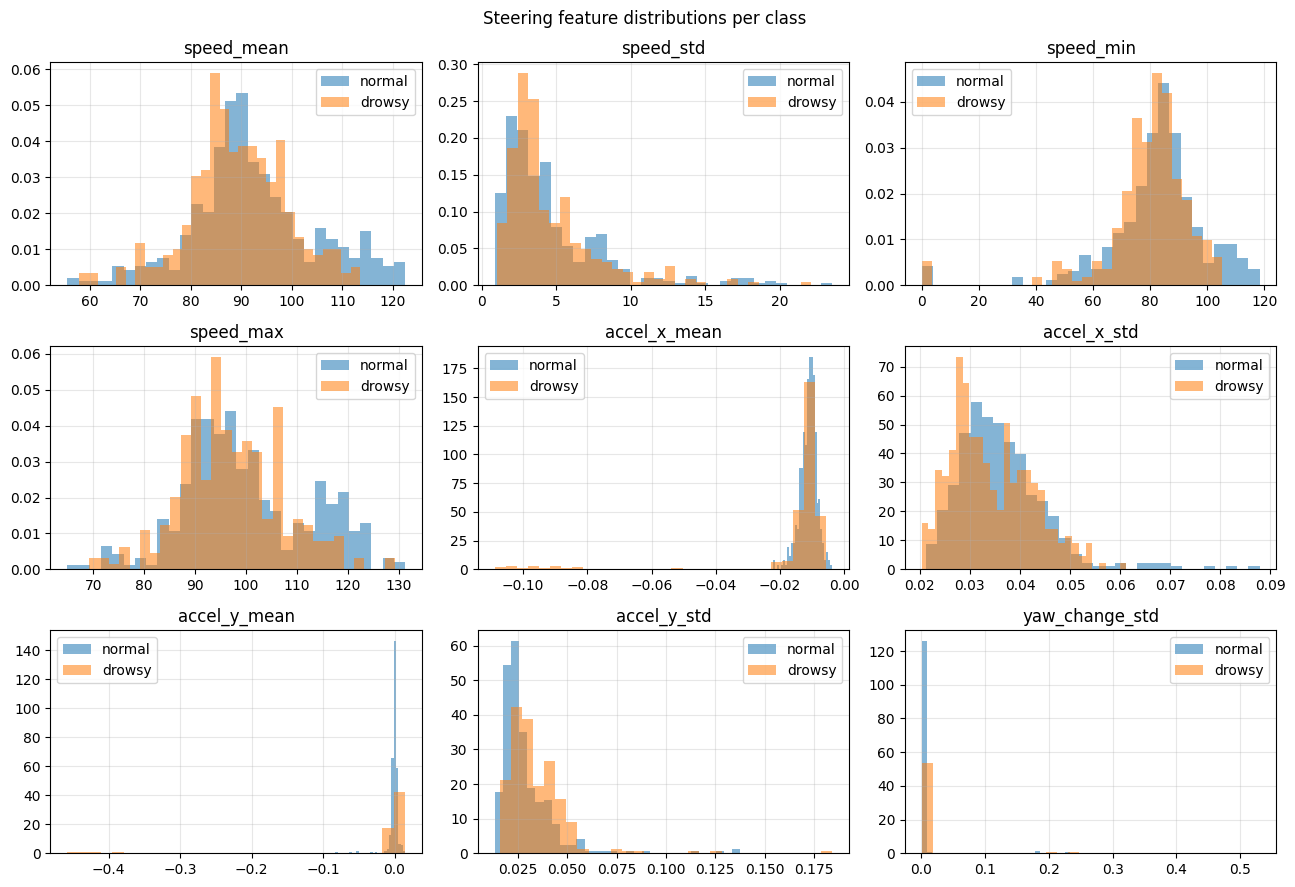

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(13, 9))
for ax, col in zip(axes.flatten(), FEATURE_COLS):
    drowsy_vals = df.loc[df.label == 1, col]
    normal_vals = df.loc[df.label == 0, col]
    ax.hist(normal_vals, bins=30, alpha=0.55, label="normal", density=True)
    ax.hist(drowsy_vals, bins=30, alpha=0.55, label="drowsy", density=True)
    ax.set_title(col); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle("Steering feature distributions per class")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "steering_feature_distributions.png", dpi=120)
plt.show()


## 7. Model and training

Same MLP architecture as the face modality, taking standardised steering
features as input.


In [13]:
N_FEATURES = X_train.shape[1]
model = SteeringMLP(n_features=N_FEATURES, num_classes=2, dropout=0.25).to(DEVICE)
print(model)
print(f"\nTrainable parameters: {model.count_parameters():,}")


SteeringMLP(
  (classifier): Sequential(
    (0): Linear(in_features=9, out_features=32, bias=True)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU(inplace=True)
    (5): Linear(in_features=16, out_features=2, bias=True)
  )
)

Trainable parameters: 882


In [14]:
EPOCHS = 50
LEARNING_RATE = 1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
loss_fn = nn.CrossEntropyLoss()

MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)
BEST_WEIGHTS_PATH = MODELS_DIR / "steering_mlp.pt"
np.save(MODELS_DIR / "steering_mlp_norm_mu.npy",  mu.squeeze())
np.save(MODELS_DIR / "steering_mlp_norm_sig.npy", sig.squeeze())

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0


def run_epoch(loader, training: bool):
    model.train(training)
    total_loss, total_correct, total_n = 0.0, 0, 0
    context = torch.enable_grad() if training else torch.no_grad()
    with context:
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            loss = loss_fn(logits, y)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * x.size(0)
            total_correct += (logits.argmax(1) == y).sum().item()
            total_n += x.size(0)
    return total_loss / total_n, total_correct / total_n


for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_dl, training=True)
    val_loss, val_acc = run_epoch(val_dl, training=False)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    marker = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), BEST_WEIGHTS_PATH)
        marker = "  <- best, saved"

    print(f"Epoch {epoch:2d}/{EPOCHS}  "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.3f}  "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.3f}{marker}")

print(f"\nBest validation accuracy: {best_val_acc:.3f}")
print(f"Saved best weights to: {BEST_WEIGHTS_PATH}")


Epoch  1/50  train_loss=0.6954 train_acc=0.483  val_loss=0.6894 val_acc=0.590  <- best, saved
Epoch  2/50  train_loss=0.6847 train_acc=0.608  val_loss=0.6852 val_acc=0.607  <- best, saved
Epoch  3/50  train_loss=0.6762 train_acc=0.634  val_loss=0.6816 val_acc=0.623  <- best, saved
Epoch  4/50  train_loss=0.6703 train_acc=0.640  val_loss=0.6784 val_acc=0.623
Epoch  5/50  train_loss=0.6618 train_acc=0.650  val_loss=0.6749 val_acc=0.615
Epoch  6/50  train_loss=0.6508 train_acc=0.655  val_loss=0.6710 val_acc=0.631  <- best, saved
Epoch  7/50  train_loss=0.6409 train_acc=0.650  val_loss=0.6671 val_acc=0.631
Epoch  8/50  train_loss=0.6362 train_acc=0.657  val_loss=0.6602 val_acc=0.648  <- best, saved
Epoch  9/50  train_loss=0.6315 train_acc=0.655  val_loss=0.6510 val_acc=0.639
Epoch 10/50  train_loss=0.6176 train_acc=0.671  val_loss=0.6412 val_acc=0.656  <- best, saved
Epoch 11/50  train_loss=0.6171 train_acc=0.669  val_loss=0.6251 val_acc=0.689  <- best, saved
Epoch 12/50  train_loss=0.6125

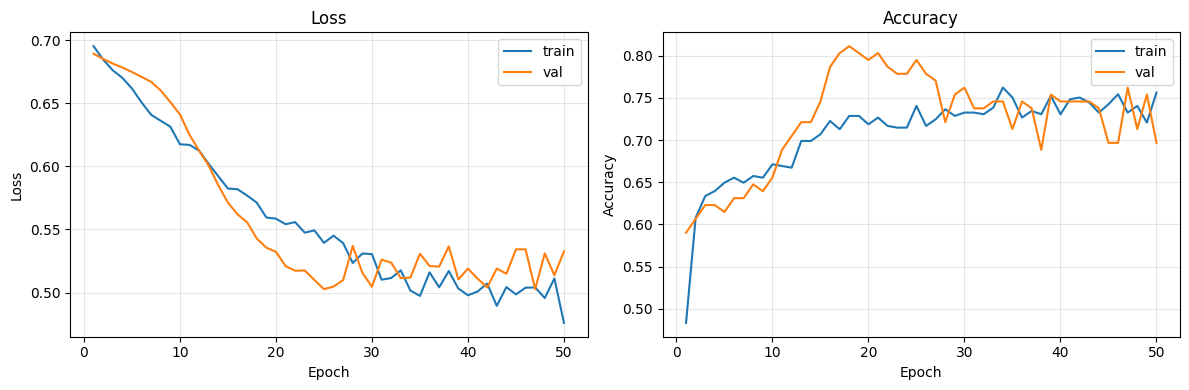

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs_x = range(1, len(history["train_loss"]) + 1)
ax1.plot(epochs_x, history["train_loss"], label="train")
ax1.plot(epochs_x, history["val_loss"], label="val")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.set_title("Loss")
ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(epochs_x, history["train_acc"], label="train")
ax2.plot(epochs_x, history["val_acc"], label="val")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy"); ax2.set_title("Accuracy")
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "steering_training_curves.png", dpi=120)
plt.show()


## 8. Test set evaluation

Evaluation on the held-out test driver. With only one driver in the test
split, results carry irreducible variance from that particular driver's
style — but the methodology is clean (no train-test driver leakage).


In [17]:
model.load_state_dict(torch.load(BEST_WEIGHTS_PATH, map_location=DEVICE, weights_only=True))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for x, y in test_dl:
        x = x.to(DEVICE)
        logits = model(x)
        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(y.tolist())
        all_probs.extend(probs[:, 1].cpu().tolist())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

acc = accuracy_score(all_labels, all_preds)
prec, rec, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="binary", pos_label=1, zero_division=0
)

print(f"Test set: {len(all_labels):,} windows from driver(s) {sorted(test_drv)}")
print(f"\nAccuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}  (positive class = drowsy)")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\n" + classification_report(
    all_labels, all_preds, target_names=["normal", "drowsy"], digits=4, zero_division=0
))


Test set: 113 windows from driver(s) ['D1']

Accuracy:  0.5044
Precision: 0.4035  (positive class = drowsy)
Recall:    0.5111
F1-score:  0.4510

              precision    recall  f1-score   support

      normal     0.6071    0.5000    0.5484        68
      drowsy     0.4035    0.5111    0.4510        45

    accuracy                         0.5044       113
   macro avg     0.5053    0.5056    0.4997       113
weighted avg     0.5260    0.5044    0.5096       113



In [ ]:
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Greens")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["normal", "drowsy"])
ax.set_yticklabels(["normal", "drowsy"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Steering MLP — Test Set Confusion Matrix")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black",
                fontsize=14)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "steering_confusion_matrix.png", dpi=120)
plt.show()


## 9. Feature importance (permutation)

Which features contribute most to the prediction? This is direct
material for the dissertation Discussion section.


Base test accuracy: 0.5044

Permutation importance (drop in accuracy when feature is shuffled):
        yaw_change_std: +0.0637 ± 0.0142
            speed_mean: +0.0035 ± 0.0106
          accel_y_mean: +0.0018 ± 0.0035
          accel_x_mean: -0.0000 ± 0.0186
             speed_max: -0.0018 ± 0.0152
             speed_std: -0.0035 ± 0.0173
           accel_x_std: -0.0124 ± 0.0348
             speed_min: -0.0124 ± 0.0214
           accel_y_std: -0.1274 ± 0.0235


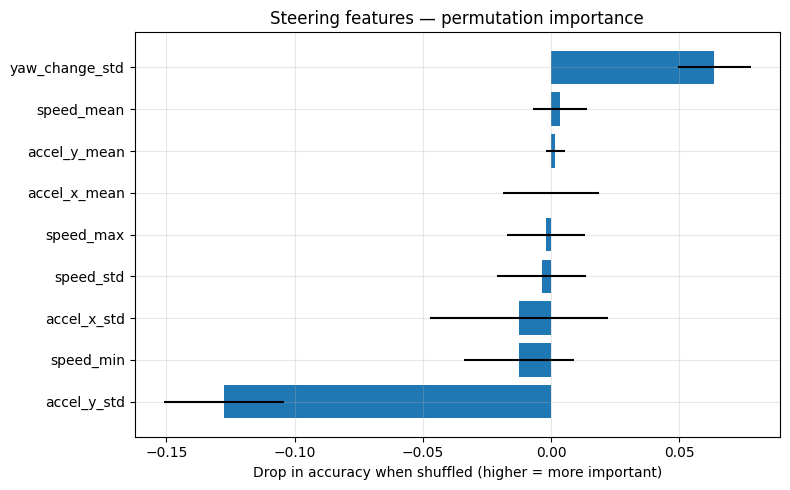

In [18]:
def permutation_importance(model, X, y, n_repeats=5):
    model.eval()
    rng_local = np.random.default_rng(SEED)

    def acc_of(X_arr):
        with torch.no_grad():
            preds = model(torch.tensor(X_arr).to(DEVICE)).argmax(1).cpu().numpy()
        return float((preds == y).mean())

    base = acc_of(X)
    drops = {}
    for j, name in enumerate(FEATURE_COLS):
        ds = []
        for _ in range(n_repeats):
            X_perm = X.copy()
            rng_local.shuffle(X_perm[:, j])
            ds.append(base - acc_of(X_perm))
        drops[name] = (float(np.mean(ds)), float(np.std(ds)))
    return base, drops


base_acc, importances = permutation_importance(model, X_test, y_test)
print(f"Base test accuracy: {base_acc:.4f}\n")

names = list(importances.keys())
means = [importances[n][0] for n in names]
stds  = [importances[n][1] for n in names]

order = np.argsort(means)[::-1]

print("Permutation importance (drop in accuracy when feature is shuffled):")
for i in order:
    print(f"  {names[i]:>20s}: {means[i]:+.4f} ± {stds[i]:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh([names[i] for i in order[::-1]], [means[i] for i in order[::-1]],
        xerr=[stds[i] for i in order[::-1]])
ax.set_xlabel("Drop in accuracy when shuffled (higher = more important)")
ax.set_title("Steering features — permutation importance")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "steering_feature_importance.png", dpi=120)
plt.show()


## 10. Summary

Trained model weights at `models/steering_mlp.pt` along with normalisation
statistics. The notebook completes the third of four modality experiments
in the dissertation comparison.

### What goes in the dissertation from this notebook
- Training curves (`steering_training_curves.png`)
- Confusion matrix (`steering_confusion_matrix.png`)
- Feature distributions (`steering_feature_distributions.png`)
- Permutation importance (`steering_feature_importance.png`)
- Accuracy / precision / recall / F1 from §8
- Discussion: which steering / inertial features matter most for drowsiness

### Methodological notes for §3.3 / §5.7
- Driver-level split (4 train / 1 val / 1 test) — only 6 drivers available,
  so absolute test-set sizes are small and carry per-driver variance.
- Aggressive driving class excluded — binary task (NORMAL vs DROWSY).
- 60-second windows with 30-second stride. Window length is a
  hyperparameter — shorter windows give more data points but noisier
  per-window statistics; 60s balances stability and granularity.
- Lateral acceleration (`accel_y`) used as a proxy for steering input,
  since UAH-DriveSet does not include direct steering wheel angle data
  (smartphone-collected dataset).
